
Processing subject 01


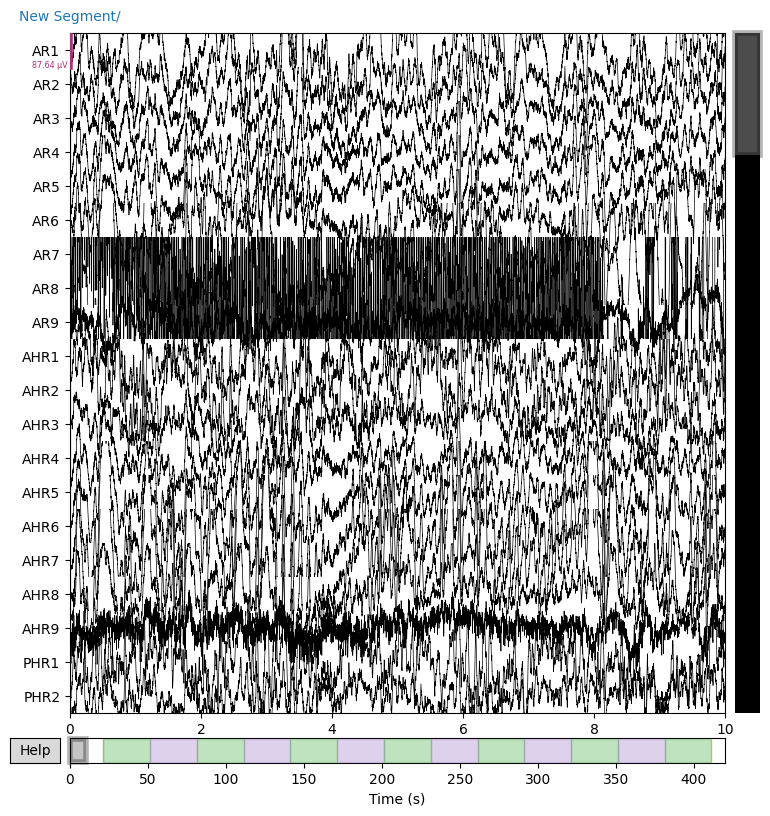

Bad channels: ['AR8', 'MKR1+', 'MFL15']


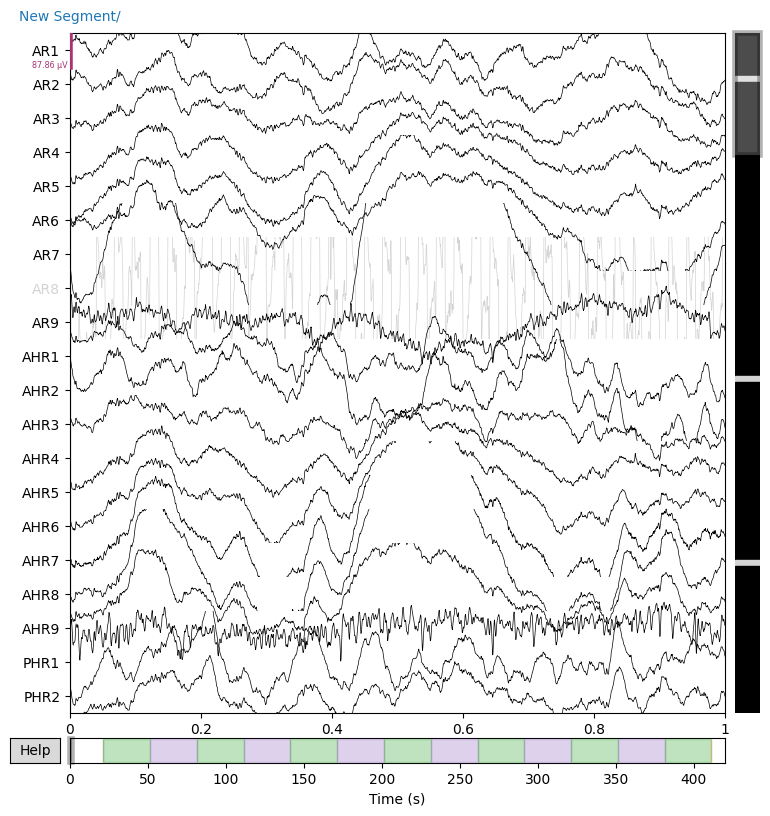

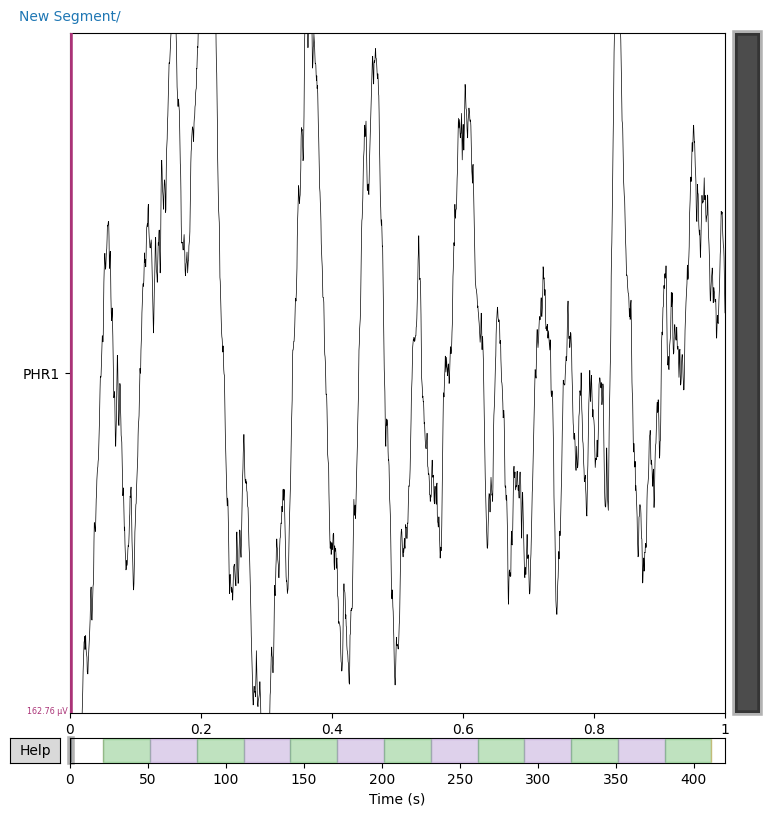

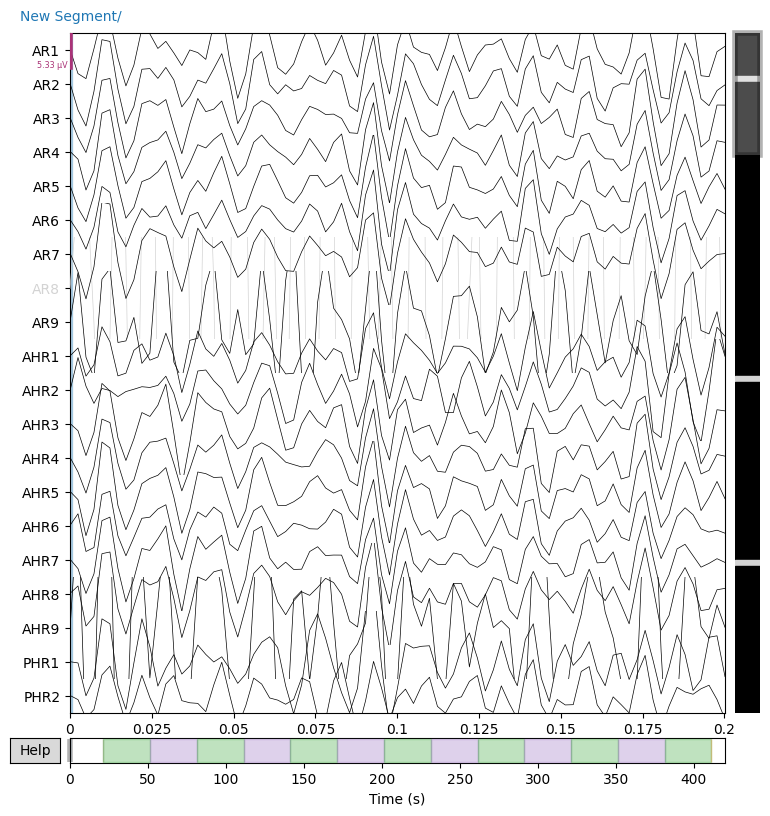

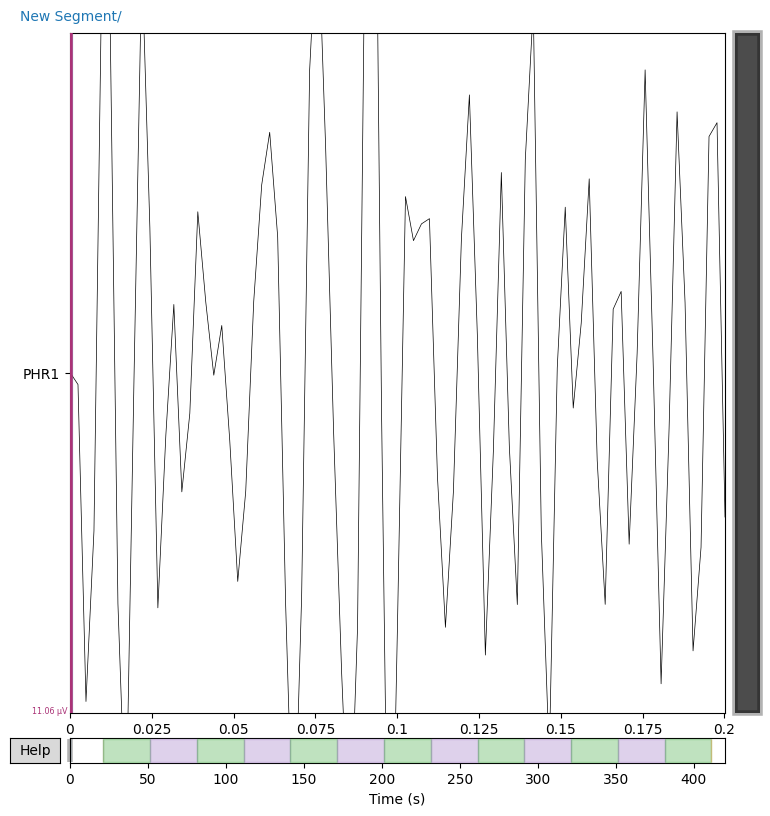

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


C:\Users\muqadasah\AppData\Local\Temp\ipykernel_13120\172253240.py:167: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.copy().compute_psd(
c:\Users\muqadasah\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


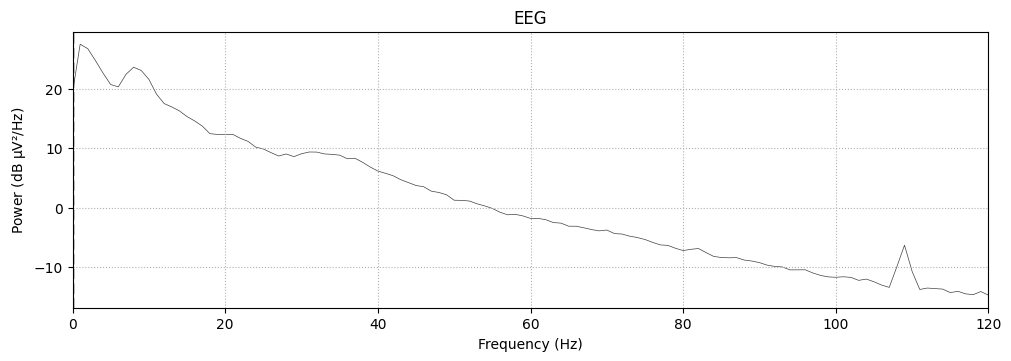

In [18]:
import os
import numpy as np
import pandas as pd
import mne
import mne_bids
from pathlib import Path

# -----------------------------
# Dataset information
# -----------------------------
bids_dir = r"E:\IEEG-FMRI Dataset"

# subject = "16"
subject ="01"

session = "iemu"
datatype = "ieeg"
task = "film"
acquisition = "clinical"

print(f"\nProcessing subject {subject}")

# ------------------------------------
# Check if iEEG session exists
# ------------------------------------
iemu_folder = Path(bids_dir) / f"sub-{subject}" / "ses-iemu"

if not iemu_folder.exists():
    raise FileNotFoundError(f"Subject {subject} has no iEEG session.")

# ------------------------------------
# Read channels.tsv
# ------------------------------------
channels_path = mne_bids.BIDSPath(
    subject=subject,
    session=session,
    datatype=datatype,
    task=task,
    acquisition=acquisition,
    suffix="channels",
    extension=".tsv",
    root=bids_dir,
)

channels = pd.read_csv(channels_path.match()[0], sep="\t")

# ------------------------------------
# Read BrainVision recording
# ------------------------------------
data_path = mne_bids.BIDSPath(
    subject=subject,
    session=session,
    datatype=datatype,
    task=task,
    acquisition=acquisition,
    suffix="ieeg",
    extension=".vhdr",
    root=bids_dir,
)

raw = mne.io.read_raw_brainvision(
    str(data_path.match()[0]),
    preload=True,
    verbose=False,
)

# ==========================================
# Plot completely raw recording
# ==========================================

# print(raw)

raw.plot(
    duration=10,
    scalings='auto',
    title=f"Subject {subject} - Raw iEEG (Before preprocessing)",
    block=True
)

# ------------------------------------
# Bad channels
# ------------------------------------
bad_channels = channels.loc[
    channels["status"] == "bad",
    "name"
].tolist()

print("Bad channels:", bad_channels)

# Mark bad channels (do not remove them)
raw.info["bads"] = bad_channels

raw.plot(
    duration=1,
    scalings='auto',
    title=f"Subject {subject} - Bad channels highlighted",
    block=True
)

# ------------------------------------
# Plot only bad channels
# ------------------------------------
# if len(bad_channels) > 0:

#     raw_bad = raw.copy().pick(bad_channels)

#     raw_bad.plot(
#         duration=1,
#         scalings='auto',
#         title=f"Subject {subject} - Bad channels only",
#         block=True
#     )

# ==========================================
# Inspect one good channel
# ==========================================

# good_channel = "CP01"  
good_channel = "PHR1"

# Raw signal
raw.copy().pick([good_channel]).plot(
    duration=1,
    scalings='auto',
    title=f"{good_channel} - Raw",
    block=True
)

# ==========================================
# High-frequency activity (all channels)
# ==========================================

raw_hfb = raw.copy()

raw_hfb.filter(
    l_freq=60,
    h_freq=120,
    verbose=False
)

raw_hfb.plot(
    duration=0.2,
    scalings='auto',
    title="High-frequency activity (60–120 Hz)",
    block=True
)

# ==========================================
# High-frequency activity (good channel)
# ==========================================

raw.copy().filter(
    l_freq=60,
    h_freq=120,
    verbose=False
).pick([good_channel]).plot(
    duration=0.2,
    scalings='auto',
    title=f"{good_channel} - 60–120 Hz",
    block=True
)

# ==========================================
# PSD of the good channel
# ==========================================

raw.copy().compute_psd(
    fmax=120
).plot(
    picks=[good_channel],
    average=False
)


Effective window size : 1.000 (s)


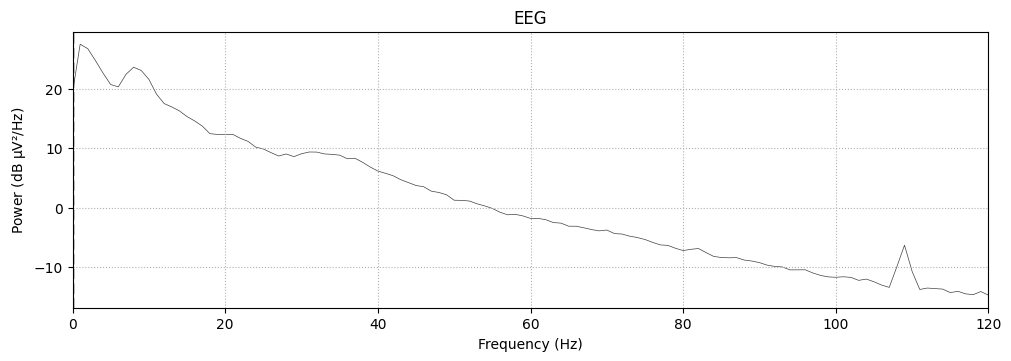

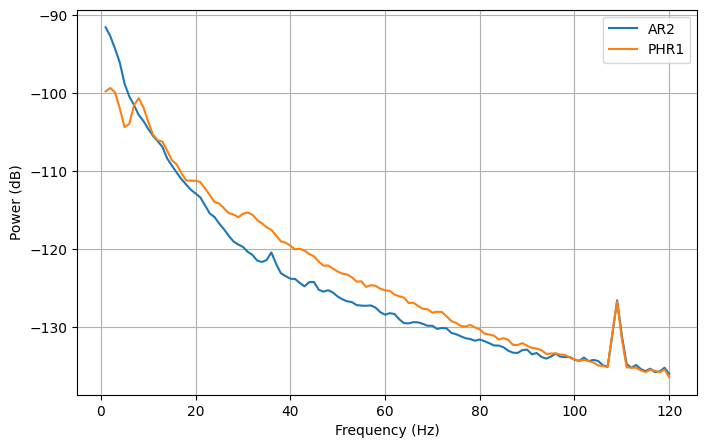

In [19]:
import matplotlib.pyplot as plt

# Choose channels to compare
channels = ["AR2", "PHR1"]
# channels = ["CP07", "CP01"]

psd = raw.compute_psd(
    method="welch",
    fmin=1,
    fmax=120
);

freqs = psd.freqs

plt.figure(figsize=(8,5))

for ch in channels:
    idx = raw.ch_names.index(ch)

    plt.plot(
        freqs,
        10*np.log10(psd.get_data()[idx]),
        label=ch
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.legend()
plt.grid(True)
plt.show()